In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Right now, we assume constant infectiousness, and hence constant gametocytes density. But in reality, the gametocytes density fluctuates. We can model this fluctuation as a random walk.

In [201]:
# Function to add logarithmic noise
def add_logarithmic_noise(x, mu, sigma):
    L = np.random.lognormal(mu, sigma)
    # Adjust to have mean 0
    E_L = np.exp(mu + (sigma**2) / 2)
    noise = L - E_L
    return max(0,x + noise)

foo = np.vectorize(add_logarithmic_noise)

In [10]:
a = np.ones(1000)*10
b = foo(a, 0, 2)

(array([780.,  88.,  30.,  31.,  15.,   7.,   3.,   8.,   2.,   6.,   6.,
          2.,   1.,   1.,   2.,   2.,   2.,   1.,   1.,   2.,   1.,   0.,
          1.,   0.,   1.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  2.61174654,   7.22366846,  11.83559039,  16.44751231,
         21.05943423,  25.67135615,  30.28327807,  34.8952    ,
         39.50712192,  44.11904384,  48.73096576,  53.34288768,
         57.95480961,  62.56673153,  67.17865345,  71.79057537,
         76.40249729,  81.01441922,  85.62634114,  90.23826306

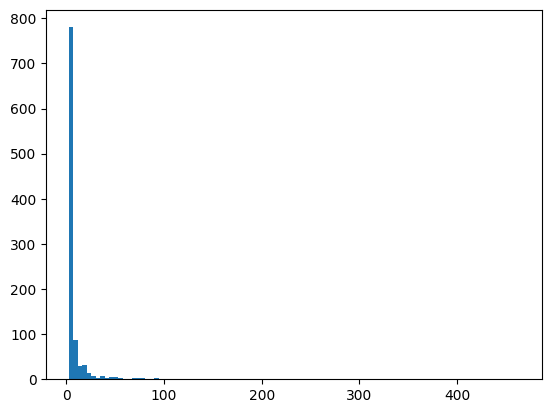

In [15]:
plt.hist(b, bins=100)

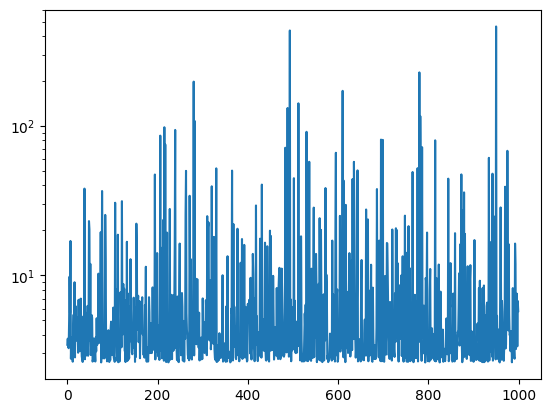

In [17]:
plt.plot(b)
plt.yscale('log')

In [19]:
np.mean(b)

9.439454428357486

In [27]:
import math

def expcdf(x, lmbda=1):
    if x < 0:
        return 0
    else:
        return 1 - math.exp(-lmbda * x)
    
def get_inv_micro_liters_blood(age_years):
    age_effective = min(age_years, 20)
    return 1e-6/(0.225*age_effective + 0.5)

base_gametocyte_mosquito_survival = 0.002011099

def infectiousness_from_gametocytes(n_gametocytes, age_years):
    inv_microliters_blood = get_inv_micro_liters_blood(age_years)
    microliters_per_bloodmeal = 1    
    fever_effect = 0
    return expcdf(n_gametocytes * inv_microliters_blood * microliters_per_bloodmeal * base_gametocyte_mosquito_survival * (1.0 - fever_effect))

def infectiousness_from_gametocyte_density(g):
    return expcdf(g*base_gametocyte_mosquito_survival)

bar = np.vectorize(infectiousness_from_gametocyte_density)

In [25]:
infectiousness_from_gametocyte_density(10)

0.019910112906792454

In [29]:
c = bar(b)

In [31]:
np.mean(c)

0.017671645798614414

In [32]:
infectiousness_from_gametocyte_density(10)

0.019910112906792454

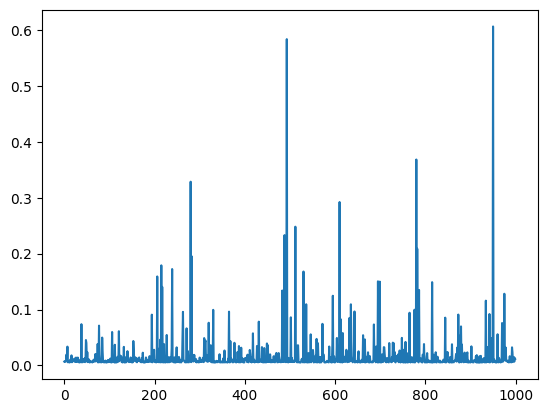

In [33]:
plt.plot(c)

In [46]:
s1 = foo(a, 0, 1.8)
s2 = foo(a, 0, 1.8)
s3 = foo(a, 0, 1.8)
s4 = foo(a, 0, 1.8)

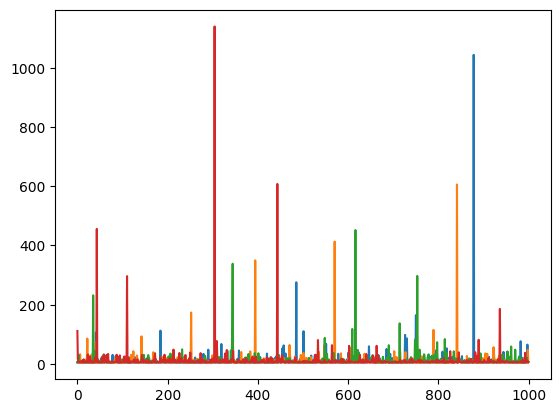

In [47]:
plt.plot(s1)
plt.plot(s2)
plt.plot(s3)
plt.plot(s4)

In [48]:
np.mean(s1)

10.820732978177661

In [49]:
np.mean(s2)

10.131401025793357

In [50]:
np.mean(s3)

10.50832329925777

In [51]:
np.mean(s4)

11.294391362451869

In [56]:
# For each day, find the fraction of the total that is in the largest of s1 through s4

r = np.zeros(len(s1))
for t in np.arange(len(s1)):
    r[t] = max(s1[t], s2[t], s3[t], s4[t])/sum([s1[t], s2[t], s3[t], s4[t]])
    

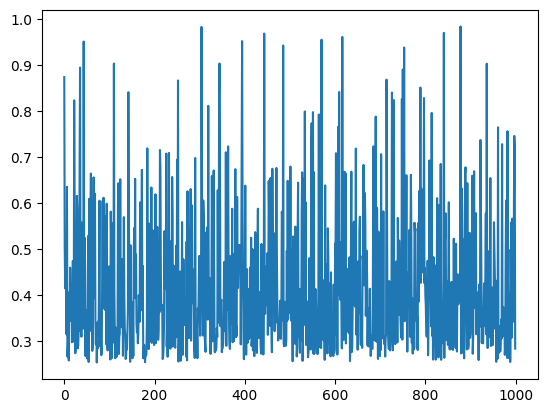

In [58]:
plt.plot(r)

In [59]:
np.mean(r)

0.41778242242417857

In [60]:
np.std(r)

0.14597355220440575

In [61]:
def was_oocyst_clonal(s1_value, s2_value, s3_value, s4_value):
    # select 2, weighted by the values
    s = [s1_value, s2_value, s3_value, s4_value]
    s = np.array(s)
    s = s/sum(s)
    s = np.random.choice([0, 1, 2, 3], 2, p=s)
    
    # return True if they are the same
    return s[0] == s[1]

In [72]:
was_oocyst_clonal(1, 1,0,0)

True

In [101]:
# Without noise
clonal_result_no_noise = np.zeros(10000)
for i in np.arange(1000):
    clonal_result_no_noise[i] = was_oocyst_clonal(10,10,10,10)
print(np.mean(clonal_result_no_noise))

# With noise
clonal_result_with_noise = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_noise[i] = was_oocyst_clonal(add_logarithmic_noise(10, 0, 2), 
                                                    add_logarithmic_noise(10, 0, 2), 
                                                    add_logarithmic_noise(10, 0, 2), 
                                                    add_logarithmic_noise(10, 0, 2))
print(np.mean(clonal_result_with_noise))

0.0277
0.3771


In [129]:
h = np.zeros(4)
for i in range(4):
    h[i] = add_logarithmic_noise(10, 0, 0)
    
print(h)
print(np.mean(h))
print(np.max(h)/np.sum(h))

[10. 10. 10. 10.]
10.0
0.25


In [170]:
# With some noise
clonal_result_with_noise = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_noise[i] = was_oocyst_clonal(10, 
                                                    10, 
                                                    10, 
                                                    0)
print(np.mean(clonal_result_with_noise))

# With some noise
clonal_result_with_noise = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_noise[i] = was_oocyst_clonal(add_logarithmic_noise(10, 0, 1), 
                                                    add_logarithmic_noise(10, 0, 1), 
                                                    add_logarithmic_noise(10, 0, 1), 
                                                    0)
print(np.mean(clonal_result_with_noise))

# With noise
clonal_result_with_noise = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_noise[i] = was_oocyst_clonal(add_logarithmic_noise(10, 0, 2), 
                                                    add_logarithmic_noise(10, 0, 2), 
                                                    add_logarithmic_noise(10, 0, 2), 
                                                    0)
print(np.mean(clonal_result_with_noise))

0.3353
0.3455
0.4592


In [233]:
xx = 0
for i in np.arange(100000):
    xx += add_logarithmic_noise(1, 0, 0.7)
print(xx/100000)

0.9995313090845096


In [270]:
add_logarithmic_noise(1, 0, 0.7)

0.05774344894140904

In [193]:
add_logarithmic_noise(1000, 0, 3)

909.9887480520695

In [194]:
# With some noise
clonal_result_with_noise = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_noise[i] = was_oocyst_clonal(10, 
                                                    100, 
                                                    1000, 
                                                    0)
print(np.mean(clonal_result_with_noise))

# With some noise
clonal_result_with_noise = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_noise[i] = was_oocyst_clonal(add_logarithmic_noise(10, 0, 1), 
                                                    add_logarithmic_noise(100, 0, 2), 
                                                    add_logarithmic_noise(1000, 0, 3), 
                                                    0)
print(np.mean(clonal_result_with_noise))

# With noise
clonal_result_with_noise = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_noise[i] = was_oocyst_clonal(add_logarithmic_noise(10, 0, 2), 
                                                    add_logarithmic_noise(100, 0, 3), 
                                                    add_logarithmic_noise(1000, 0, 3), 
                                                    0)
print(np.mean(clonal_result_with_noise))

0.8186
0.8149
0.9277


In [207]:
add_logarithmic_noise(1, 0, 1)

0

# How much does sawtooth (see gametocyte_flucations_in_emod.ipynb) change infectiousness?

In [271]:
df_sawtooth = pd.read_csv('sawtooth.csv')

In [273]:
sawtooth = df_sawtooth['f'].values

In [1]:
sawtooth.round(2)

NameError: name 'sawtooth' is not defined

In [275]:
np.mean(sawtooth)

1.0000000000000002

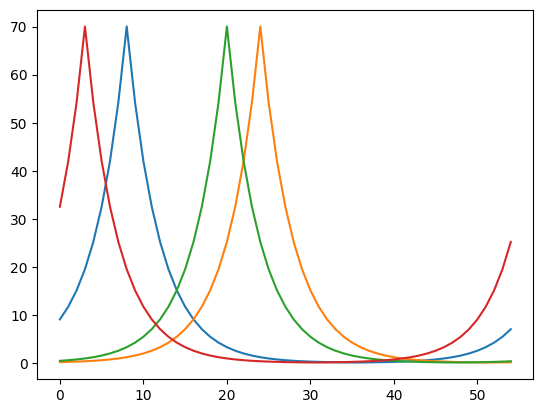

In [284]:
# Let s1-s4 be identical, but with random phase offsets
s1_sawtooth = np.roll(sawtooth, np.random.randint(55)) * 10
s2_sawtooth = np.roll(sawtooth, np.random.randint(55)) * 10
s3_sawtooth = np.roll(sawtooth, np.random.randint(55)) * 10
s4_sawtooth = np.roll(sawtooth, np.random.randint(55)) * 10

plt.plot(s1_sawtooth)
plt.plot(s2_sawtooth)
plt.plot(s3_sawtooth)
plt.plot(s4_sawtooth)

In [296]:
# With some noise
clonal_result_with_mean = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_mean[i] = was_oocyst_clonal(10, 
                                                    10, 
                                                    10, 
                                                    10)
print(np.mean(clonal_result_with_mean))

# With sawtooths
clonal_result_with_sawtooth = np.zeros(10000)
for i in np.arange(10000):
    clonal_result_with_sawtooth[i] = was_oocyst_clonal(10*np.random.choice(sawtooth), 
                                                       10*np.random.choice(sawtooth),
                                                       10*np.random.choice(sawtooth),
                                                       10*np.random.choice(sawtooth))
print(np.mean(clonal_result_with_sawtooth))

0.2586
0.5793


In [298]:
# With some noise
clonal_result_with_mean = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_mean[i] = was_oocyst_clonal(10, 
                                                    10, 
                                                    0, 
                                                    0)
print(np.mean(clonal_result_with_mean))

# With sawtooths
clonal_result_with_sawtooth = np.zeros(10000)
for i in np.arange(10000):
    clonal_result_with_sawtooth[i] = was_oocyst_clonal(10*np.random.choice(sawtooth), 
                                                       10*np.random.choice(sawtooth),
                                                       0,
                                                       0)
print(np.mean(clonal_result_with_sawtooth))

0.4936
0.7724


In [299]:
# With some noise
clonal_result_with_mean = np.zeros(10000)
for i in np.arange(10000):
    # clonal_result_with_noise[i] = was_oocyst_clonal(s1[i], s2[i], s3[i], s4[i])
    clonal_result_with_mean[i] = was_oocyst_clonal(10, 
                                                    10, 
                                                    10, 
                                                    0)
print(np.mean(clonal_result_with_mean))

# With sawtooths
clonal_result_with_sawtooth = np.zeros(10000)
for i in np.arange(10000):
    clonal_result_with_sawtooth[i] = was_oocyst_clonal(10*np.random.choice(sawtooth), 
                                                       10*np.random.choice(sawtooth),
                                                       10*np.random.choice(sawtooth),
                                                       0)
print(np.mean(clonal_result_with_sawtooth))

0.3287
0.6603
